# Meta-Training Loop

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import torch
import numpy as np
sys.path.append(str(Path.cwd().parent / 'src'))
import copy
from dvrp_env import DVRPEnv
from dvrp_agent import PPOAgent
from or_tools import darp_solver
from dvrp_embedding import EmbeddingFFN

In [2]:
ACTION_SPACE_MAP = [
    (-30, 0), (-30, 10), (-30, 20), (-30, 30),
    (-20, 0), (-20, 10), (-20, 20), (-20, 30),
    (-10, 0), (-10, 10), (-10, 20), (-10, 30),
    (0, 0),   (0, 10),   (0, 20),   (0, 30),
]

FLEXIBILITY_PERSONALITIES = [
    "flexible for late dropoff, but inflexible for early pickup",
    "flexible for early pickup, but inflexible for late dropoff",
    "inflexible for any schedule changes",
    "flexible for both early pickup and late dropoff",
]


In [3]:
data_dir = Path.cwd().parent / "data/results"
checkpoint_dir = Path.cwd().parent / "checkpoints"

sns.set_style('darkgrid')

In [4]:
acc_1  = pd.read_csv(data_dir / 'acc_1.csv')
acc_2 = pd.read_csv(data_dir / 'acc_2.csv')
imp_1 = pd.read_csv(data_dir / "imp_1.csv")
imp_2 = pd.read_csv(data_dir / "imp_2.csv")
val_1 = pd.read_csv(data_dir / "val_1.csv")
val_2 = pd.read_csv(data_dir / "val_2.csv")
pol_1 = pd.read_csv(data_dir / "pol_1.csv")
pol_2 = pd.read_csv(data_dir / "pol_2.csv")

acc = pd.merge(left = acc_1, right = acc_2, left_on = 'Step', right_on = 'Step',  how='inner')
imp = pd.merge(left = imp_1, right = imp_2, left_on = 'Step', right_on = 'Step',  how='inner')
val = pd.merge(left = val_1, right = val_2, left_on = 'Step', right_on = 'Step',  how='inner')
pol = pd.merge(left = pol_1, right = pol_2, left_on = 'Step', right_on = 'Step',  how='inner')


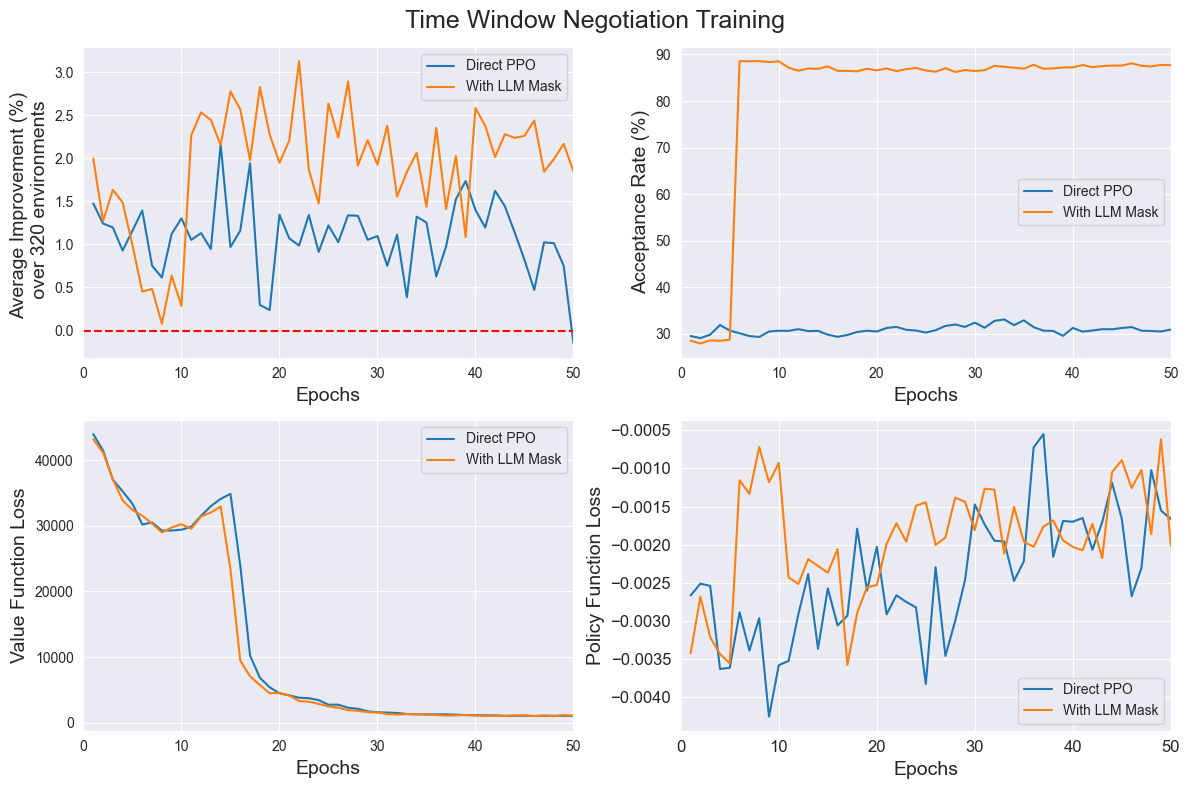

In [5]:
fig, axes = plt.subplots(2,2,figsize=(12,8))

sns.lineplot(data=acc, x='Step', y="Value_x", label="Direct PPO", ax=axes[0,1])
sns.lineplot(data=acc, x='Step', y="Value_y", label="With LLM Mask", ax=axes[0,1])
sns.lineplot(data=imp, x='Step', y="Value_x", label="Direct PPO", ax=axes[0,0])
sns.lineplot(data=imp, x='Step', y="Value_y", label="With LLM Mask", ax=axes[0,0])

sns.lineplot(data=val, x='Step', y="Value_x", label="Direct PPO", ax=axes[1,0])
sns.lineplot(data=val, x='Step', y="Value_y", label="With LLM Mask", ax=axes[1,0])
sns.lineplot(data=pol, x='Step', y="Value_x", label="Direct PPO", ax=axes[1,1])
sns.lineplot(data=pol, x='Step', y="Value_y", label="With LLM Mask", ax=axes[1,1])


fig.suptitle("Time Window Negotiation Training", fontsize=18)

axes[0,1].set_ylabel("Acceptance Rate (%)", fontsize=14)
axes[0,0].set_ylabel("Average Improvement (%) \n over 320 environments",fontsize=14 )
axes[1,0].set_ylabel("Value Function Loss",fontsize=14 )
axes[1,1].set_ylabel("Policy Function Loss",fontsize=14 )

axes[0,0].axhline(y=0, color='red', linestyle='--')
for ax in axes.flatten():
    ax.set_xlim(0,50)
    ax.set_xlabel("Epochs", fontsize=14)


plt.tick_params(labelsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# Revert to OR Tools Comp

In [6]:
traveler_decisions_path = str(Path.cwd().parent / "src/traveler_decisions_augmented.csv")
model_path = str(Path.cwd().parent / "checkpoints/refined/best.pt")
traveler_decisions = pd.read_csv(traveler_decisions_path)
trip_types = pd.read_csv(str(Path.cwd().parent / "src/traveler_trip_types_res_7.csv"))
env = DVRPEnv(
        num_customers=30,
        batch_size=1,
        traveler_decisions_path=traveler_decisions_path,
        model_path=model_path)

tt_matrix = env.data_generator.generator.travel_time_matrix.to('cpu') 
sigma = tt_matrix[tt_matrix>0].median()
tt_matrix = torch.exp(-tt_matrix**2 / sigma**2)

agent = PPOAgent(
        travel_time_matrix=tt_matrix,
        gcn_hidden=128,
        gcn_out=32,
        time_embed_dim=16,
        time_vocab_size=22, 
        transformer_embed_dim=128,
        action_dim=16,
        hidden_dim=512,
        policy_lr=1e-4,
        value_lr=3e-4,
        gamma=0.99,
        gae_lambda=0.95,
        device='cpu',
        entropy_coef=1e-4,
        clip_epsilon=0.1
    )
random_agent = copy.deepcopy(agent)
agent.load(checkpoint_dir / "meta_train_Mar30_2/policy_ep80.pt")


In [ ]:
def get_masks(
    env: DVRPEnv, # batched
    user_ids: np.ndarray, # 1d array of users at "this step"
    target_flexibilities: torch.Tensor, # [batch_size, num_users] or [batch_size],
    decisions, 
    device: str
) -> torch.Tensor:
    """
    Compute action masks for the batched environment based on traveler constraints
    and the PREDICTED FLEXIBILITY
    This mask is looked up from the augmented csv. # we take this to be from LLM: guessing a mask
    Information to lookup: traveler_id, flexibility, trip_purpose, departure_location, arrival_location -> Mask over 16 actions
    """
    batch_size = target_flexibilities  # Should be number of environments (300)
    
    num_actions = 16
    
    # Default: Allow all actions (1s)

    masks = torch.ones((batch_size, num_actions), dtype=torch.float32, device=device)
    
    flexibility_columns = FLEXIBILITY_PERSONALITIES

    # For each environment in the batch

    u_id = user_ids
    #print(u_id)
    # Get metadata for this specific user in this specific environment
    user_meta = env.pending_requests['trip_metadata'][0][u_id]
    #
    # Get predicted flexibility for this environment
    flex_idx = target_flexibilities
    flex_col = flexibility_columns[flex_idx]
    #print(flex_col)
    # Build mask for all 16 actions for this environment
    decisions = env.decision_lookup
    action_mask = []

    base_key = (
        int(u_id),
        str(user_meta["trip_purpose"]).strip(),
        str(user_meta["departure_location"]).strip(),
        str(user_meta["arrival_location"]).strip(),
    )
    for pickup_shift, dropoff_shift in ACTION_SPACE_MAP:
        pickup_shift_min = abs(pickup_shift)
        dropoff_shift_min = abs(dropoff_shift)
        key = base_key + (int(pickup_shift_min), int(dropoff_shift_min))
        #print(key)
        user_decisions_per_type = decisions.get(key)[1]
        #print(user_decisions_per_type)
        
        if user_decisions_per_type is None:
            print("Not found decision error")
        decision = user_decisions_per_type[flex_idx]
        action_mask.append(1.0 if decision else 0.0)

    #print(action_mask)
    masks = torch.tensor(action_mask, device=device, dtype=torch.float32)
    #print(masks)
    masks[12] = 1.0
    return masks  # [batch_size, 16]


In [31]:
from tqdm import tqdm
import random
baseline_results = []
trained_results = []
random_results = []

for _ in tqdm(range(300)):
    obs, info = env.reset()
    baseline = copy.deepcopy(env)
    rd_agent_env = copy.deepcopy(env)
    rd_agent_obs = copy.deepcopy(obs)

    baseline_results.append(darp_solver(time_limit_seconds=1, td= baseline.pending_requests)['total_distance'])

    for i in range(30):
        u_id = i+1 
        target_flex_df = trip_types[trip_types["traveler_id"] == u_id]
        target_flex = target_flex_df["flexibility"].iloc[0]
        flex_id = FLEXIBILITY_PERSONALITIES.index(target_flex)
        masks = get_masks(env, u_id, flex_id, decisions=traveler_decisions,device='cpu')
        action = agent.select_action_batch(obs, masks=masks)
        p_shift, d_shift = ACTION_SPACE_MAP[action[0]]
        obs, reward, accepted, done, info = env.step(action)
        baseline.pending_requests['time_windows'][:,2*i+1,:] += p_shift*accepted
        baseline.pending_requests['time_windows'][:,2*i+2,:] += d_shift*accepted
    trained_results.append(darp_solver(time_limit_seconds=1, td=baseline.pending_requests)['total_distance'])
    for i in range(30):
        action = random.randint(0,15)
        p_shift, d_shift = ACTION_SPACE_MAP[action]
        rd_agent_obs, reward, accepted, done, info = rd_agent_env.step(action)

        rd_agent_env.pending_requests['time_windows'][:,2*i+1,:] += p_shift*accepted
        rd_agent_env.pending_requests['time_windows'][:,2*i+2,:] += d_shift*accepted
    random_results.append(darp_solver(time_limit_seconds=1, td=rd_agent_env.pending_requests)['total_distance'])


100%|██████████| 300/300 [28:06<00:00,  5.62s/it]


In [34]:
print(np.mean((np.array(baseline_results) - np.array(random_results))/np.array(baseline_results)))
print(np.mean((np.array(baseline_results) - np.array(trained_results))/np.array(baseline_results)))

0.015944468
0.025265532


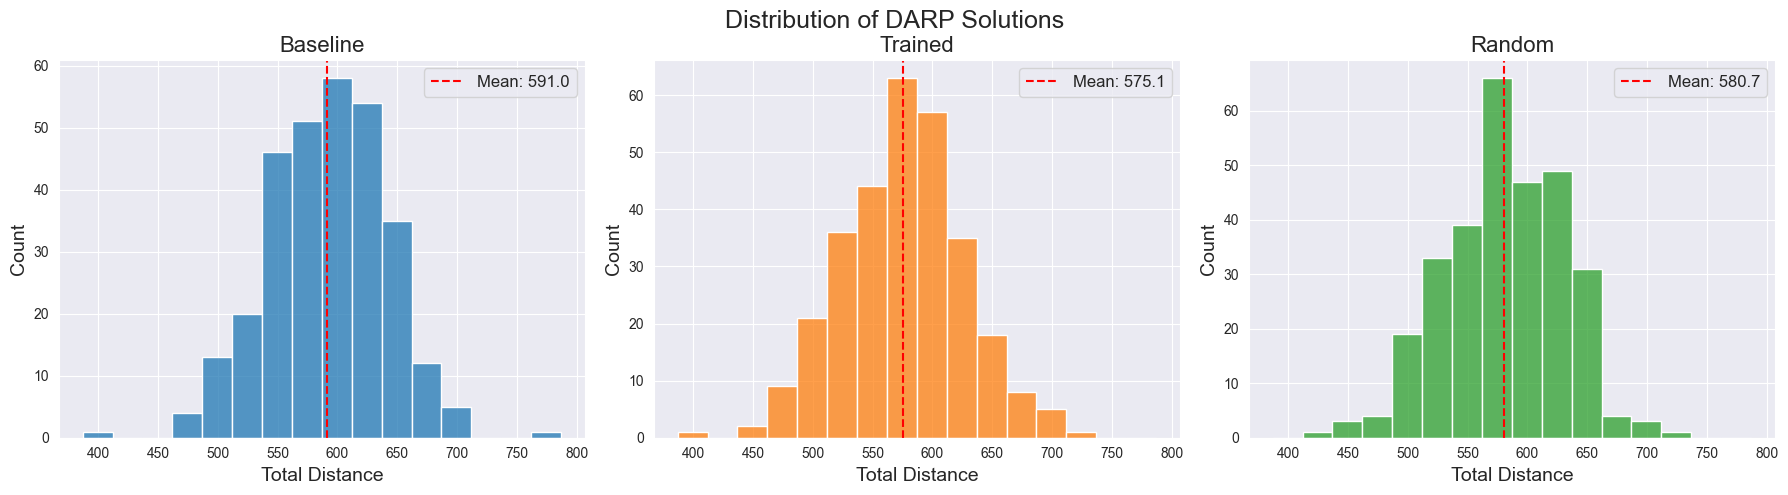

In [47]:
sns.set_style("darkgrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bins = np.arange(
    min(min(baseline_results), min(trained_results), min(random_results)),
    max(max(baseline_results), max(trained_results), max(random_results)) + 25,
    25
)

data = [baseline_results, trained_results, random_results]
labels = ['Baseline', 'Trained', 'Random']
colors = ['C0', 'C1', 'C2']

for ax, d, label, color in zip(axes, data, labels, colors):
    sns.histplot(d, bins=bins, color=color, ax=ax)
    ax.axvline(np.mean(d), color='red', linestyle='--', label=f'Mean: {np.mean(d):.1f}')
    ax.set_xlabel('Total Distance', fontsize=14)
    ax.set_ylabel('Count', fontsize=14)
    ax.set_title(label, fontsize=16)
    ax.legend(fontsize=12)

fig.suptitle('Distribution of DARP Solutions', fontsize=18)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

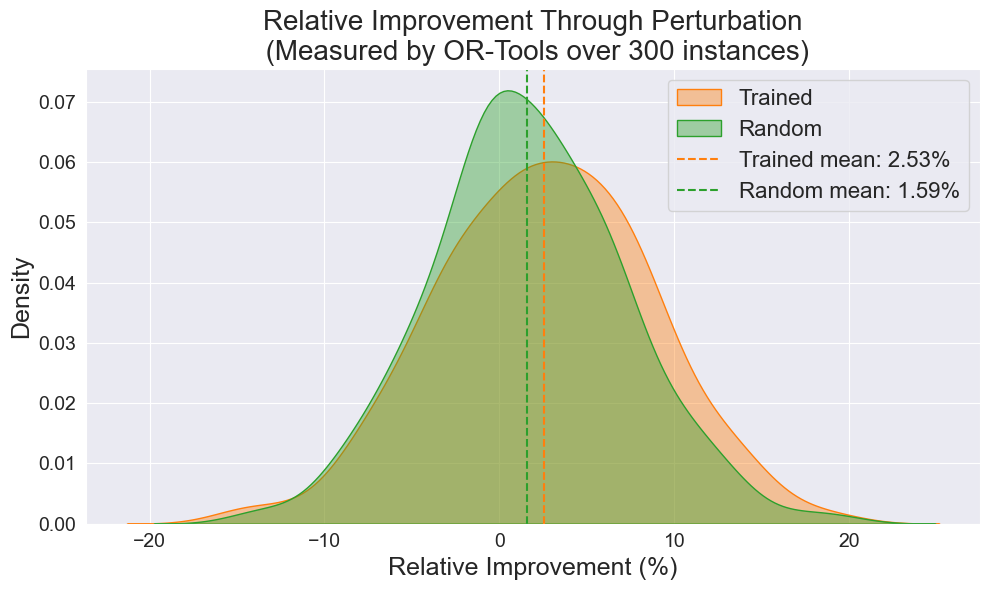

In [79]:
trained_improvement = [(b - t) / b * 100 for b, t in zip(baseline_results, trained_results)]
random_improvement = [(b - r) / b * 100 for b, r in zip(baseline_results, random_results)]

fig, ax = plt.subplots(figsize=(10, 6))

sns.kdeplot(trained_improvement, color='C1', fill=True, alpha=0.4, label='Trained', ax=ax)
sns.kdeplot(random_improvement, color='C2', fill=True, alpha=0.4, label='Random', ax=ax)

ax.axvline(np.mean(trained_improvement), color='C1', linestyle='--', label=f'Trained mean: {np.mean(trained_improvement):.2f}%')
ax.axvline(np.mean(random_improvement), color='C2', linestyle='--', label=f'Random mean: {np.mean(random_improvement):.2f}%')

ax.set_xlabel('Relative Improvement (%)', fontsize=18)
ax.set_ylabel('Density', fontsize=18)
ax.set_title('Relative Improvement Through Perturbation\n (Measured by OR-Tools over 300 instances)', fontsize=20)
ax.legend(fontsize=16)
plt.tick_params(labelsize=14)
plt.tight_layout()
plt.show()

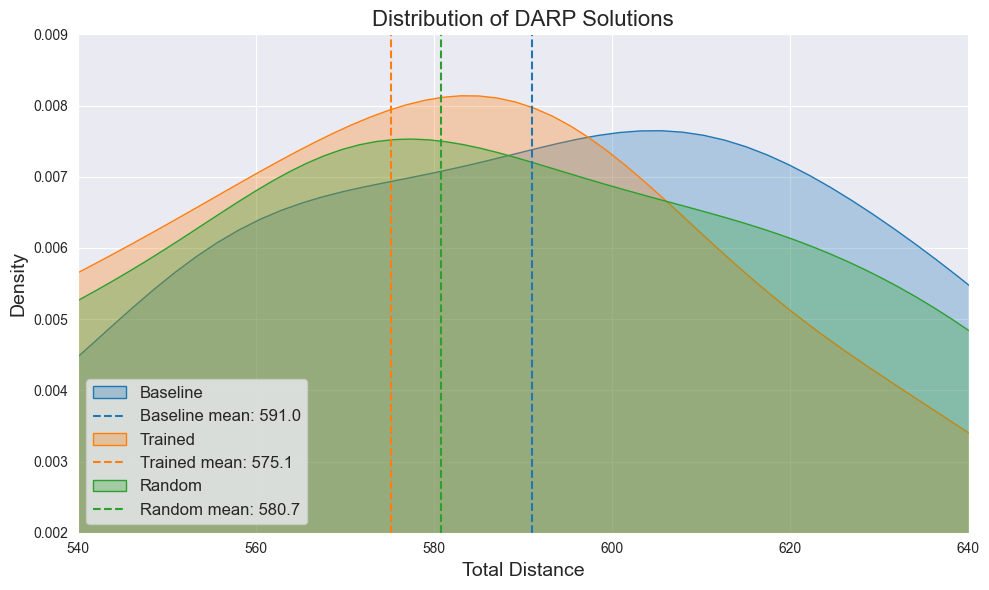

In [57]:
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(10, 6))

data = [baseline_results, trained_results, random_results]
labels = ['Baseline', 'Trained', 'Random']
colors = ['C0', 'C1', 'C2']

for d, label, color in zip(data, labels, colors):
    sns.kdeplot(d, color=color, fill=True, alpha=0.3, label=label, ax=ax)
    ax.axvline(np.mean(d), color=color, linestyle='--', label=f'{label} mean: {np.mean(d):.1f}')

ax.set_xlabel('Total Distance', fontsize=14)
ax.set_ylabel('Density', fontsize=14)
ax.set_xlim(540,640)
ax.set_ylim(0.002,0.009)
ax.set_title('Distribution of DARP Solutions', fontsize=16)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [56]:
np.std(np.array(baseline_results))

np.float32(49.437363)